# Regression Plot Comparison

Compare regression predictions across multiple checkpoints and render a publication-friendly multi-panel figure.


## 1) Setup


In [2]:
import os
import sys
import math
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

NOTEBOOK_NAME = 'regression_comparison'
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
CACHE_DIR = PROJECT_ROOT / 'notebooks' / 'cache' / NOTEBOOK_NAME
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
METRIC_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Plot Utility


In [ ]:
def canonical_split_name(name: str) -> str:
    key = str(name).strip().lower()
    mapping = {
        'train': 'Train',
        'tr': 'Train',
        'val': 'Validation',
        'valid': 'Validation',
        'validation': 'Validation',
        'test': 'Test',
        'te': 'Test',
    }
    return mapping.get(key, str(name))


def ordered_segments(data_dict, split_order=('Train', 'Validation', 'Test')):
    normalized = []
    for label, (true_vals, pred_vals) in data_dict.items():
        normalized.append((canonical_split_name(label), np.asarray(true_vals), np.asarray(pred_vals)))

    ordered = []
    for split in split_order:
        ordered.extend([item for item in normalized if item[0] == split])
    ordered.extend([item for item in normalized if item[0] not in split_order])
    return ordered


def _panel_label_from_index(i: int) -> str:
    n = i + 1
    chars = []
    while n > 0:
        n, rem = divmod(n - 1, 26)
        chars.append(chr(ord('a') + rem))
    return f"({''.join(reversed(chars))})"


def plot_multiple_regression_series(
    data_dicts,
    titles=None,
    save_path=None,
    verbose=False,
    cols=2,
    figsize_per_col=6.4,
    figsize_per_row=3.8,
    linewidth=1.8,
    pred_linestyle='--',
    true_color='k',
    pred_color='tab:orange',
    split_order=('Train', 'Validation', 'Test'),
    split_facecolors=None,
    alpha_span=0.10,
    unify_ylim=True,
    ylim_pad=0.15,
    fontsize=10,
    title_fontsize=11,
    panel_label_fontsize=11,
    ncol_legend=4,
    show=True,
):
    """Plot multi-panel regression prediction series across splits.
    
    Each panel corresponds to one model data dict with contiguous
    Train/Validation/Test segments. Optionally enforces a shared y-axis
    range across panels and exports a publication-quality figure.
    """
    if split_facecolors is None:
        split_facecolors = {
            'Train': 'tab:green',
            'Validation': 'tab:blue',
            'Test': 'tab:purple',
        }

    if len(data_dicts) == 0:
        raise ValueError('data_dicts is empty.')

    n = len(data_dicts)
    cols = min(cols, n)
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(figsize_per_col * cols, figsize_per_row * rows), squeeze=False)
    axs = axs.reshape(-1)

    global_min, global_max = np.inf, -np.inf
    if unify_ylim:
        for dd in data_dicts:
            for _, y_true, y_pred in ordered_segments(dd, split_order=split_order):
                if y_true.size:
                    global_min = min(global_min, np.nanmin(y_true), np.nanmin(y_pred))
                    global_max = max(global_max, np.nanmax(y_true), np.nanmax(y_pred))
        if not np.isfinite(global_min) or not np.isfinite(global_max):
            global_min, global_max = 0.0, 1.0
        pad = (global_max - global_min) * ylim_pad if global_max > global_min else 0.5
        y_lim = (global_min - pad, global_max + pad)
    else:
        y_lim = None

    for i, (ax, data_dict) in enumerate(zip(axs, data_dicts)):
        segments = ordered_segments(data_dict, split_order=split_order)
        cursor = 0

        for split_name, y_true, y_pred in segments:
            n_seg = len(y_true)
            if n_seg == 0:
                continue
            x = np.arange(cursor, cursor + n_seg)

            ax.axvspan(x[0], x[-1], color=split_facecolors.get(split_name, 'lightgray'), alpha=alpha_span, lw=0)
            ax.plot(x, y_true, color=true_color, lw=linewidth, label='True' if cursor == 0 else None)
            ax.plot(x, y_pred, color=pred_color, lw=linewidth, ls=pred_linestyle, label='Pred' if cursor == 0 else None)

            cursor += n_seg

        ax.set_title((titles[i] if titles and i < len(titles) else f'Model {i+1}'), fontsize=title_fontsize)
        ax.text(0.01, 0.99, _panel_label_from_index(i), transform=ax.transAxes, va='top', ha='left', fontsize=panel_label_fontsize)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=fontsize)
        if y_lim is not None:
            ax.set_ylim(*y_lim)

    for j in range(n, len(axs)):
        axs[j].axis('off')

    split_handles = [
        Patch(facecolor=split_facecolors[k], alpha=alpha_span, label=k)
        for k in split_order if k in split_facecolors
    ]
    line_handles = [
        Line2D([0], [0], color=true_color, lw=linewidth, label='True'),
        Line2D([0], [0], color=pred_color, lw=linewidth, ls=pred_linestyle, label='Pred'),
    ]
    fig.legend(handles=line_handles + split_handles, loc='lower center', ncol=ncol_legend, frameon=False)

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        if verbose:
            print(f'Saved plot to: {save_path}')

    if show:
        plt.show()
    else:
        plt.close(fig)


## 3) Build `data_dicts` From Checkpoints


In [4]:
from src.train.config_setup import load_and_prepare_model
from src.data.preparation import prepare_data, prepare_data_lstm
from src.train.regressor_train_step import get_data_dict


def get_data_dicts_from_checkpoints(experiments, device):
    """Load checkpoints and build per-split regression predictions.
    
    Reuses prepared dataloaders by ``(prepare_fn.__name__, dataset)``
    to avoid redundant data preparation across experiments.
    """
    data_dicts = []
    titles = []
    loader_cache = {}

    for exp in experiments:
        checkpoint_path = Path(exp['checkpoint'])
        if not checkpoint_path.exists():
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

        model, args = load_and_prepare_model(
            checkpoint_path=checkpoint_path,
            device=device,
            compile=False,
        )

        prepare_fn = exp['prepare_fn']
        cache_key = (prepare_fn.__name__, args.dataset)

        if cache_key not in loader_cache:
            _, train_loader, val_loader, test_loader, _ = prepare_fn(
                base_dir=str(PROJECT_ROOT / 'data' / args.dataset),
                args=args,
            )
            loader_cache[cache_key] = (train_loader, val_loader, test_loader)

        train_loader, val_loader, test_loader = loader_cache[cache_key]
        data_dict = get_data_dict([train_loader, val_loader, test_loader], model, device)

        data_dicts.append(data_dict)
        titles.append(exp['title'])

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return data_dicts, titles


## 4) Experiment Config and Cache


In [5]:
EXPERIMENTS = [
       {
        'title': 'LSTM',
        'checkpoint': PROJECT_ROOT / 'checkpoints/lstm_20260510-212317' / 'best_model_1.pth',
        'prepare_fn': prepare_data_lstm,
    },
    {
        'title': 'EM-EQF',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_reg_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': r'EM-EQF (+$\log(\Delta t)$)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_log_pretrain_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-T-XPOS)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_minus_txpos_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-TMAP)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_minus_tmap_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-Pretrain)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_log_pretrain_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
]

CACHE_PATH = CACHE_DIR / 'reg_data_dicts.pkl'
USE_CACHE = True
SAVE_CACHE = True

if USE_CACHE and CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        cached = pickle.load(f)

    if isinstance(cached, dict):
        data_dicts = cached['data_dicts']
        titles = cached.get('titles', [exp['title'] for exp in EXPERIMENTS])
    else:
        data_dicts = cached
        titles = [exp['title'] for exp in EXPERIMENTS][:len(data_dicts)]

    print(f'Loaded cached data_dicts from: {CACHE_PATH}')
else:
    data_dicts, titles = get_data_dicts_from_checkpoints(EXPERIMENTS, DEVICE)

    if SAVE_CACHE:
        with open(CACHE_PATH, 'wb') as f:
            pickle.dump({'data_dicts': data_dicts, 'titles': titles}, f)
        print(f'Saved data_dicts to: {CACHE_PATH}')

print(f'Number of experiments: {len(data_dicts)}')
print(f'Titles: {titles}')


Loaded cached data_dicts from: /root/autodl-tmp/em_eqf/notebooks/cache/regression_comparison/reg_data_dicts.pkl
Number of experiments: 6
Titles: ['LSTM', 'EM-EQF', 'EM-EQF (+$\\log(\\Delta t)$)', 'EM-EQF (-T-XPOS)', 'EM-EQF (-TMAP)', 'EM-EQF (-Pretrain)']


## 5) Plot


Saved plot to: /root/autodl-tmp/em_eqf/notebooks/figs/regression_comparison/regression_plots.pdf


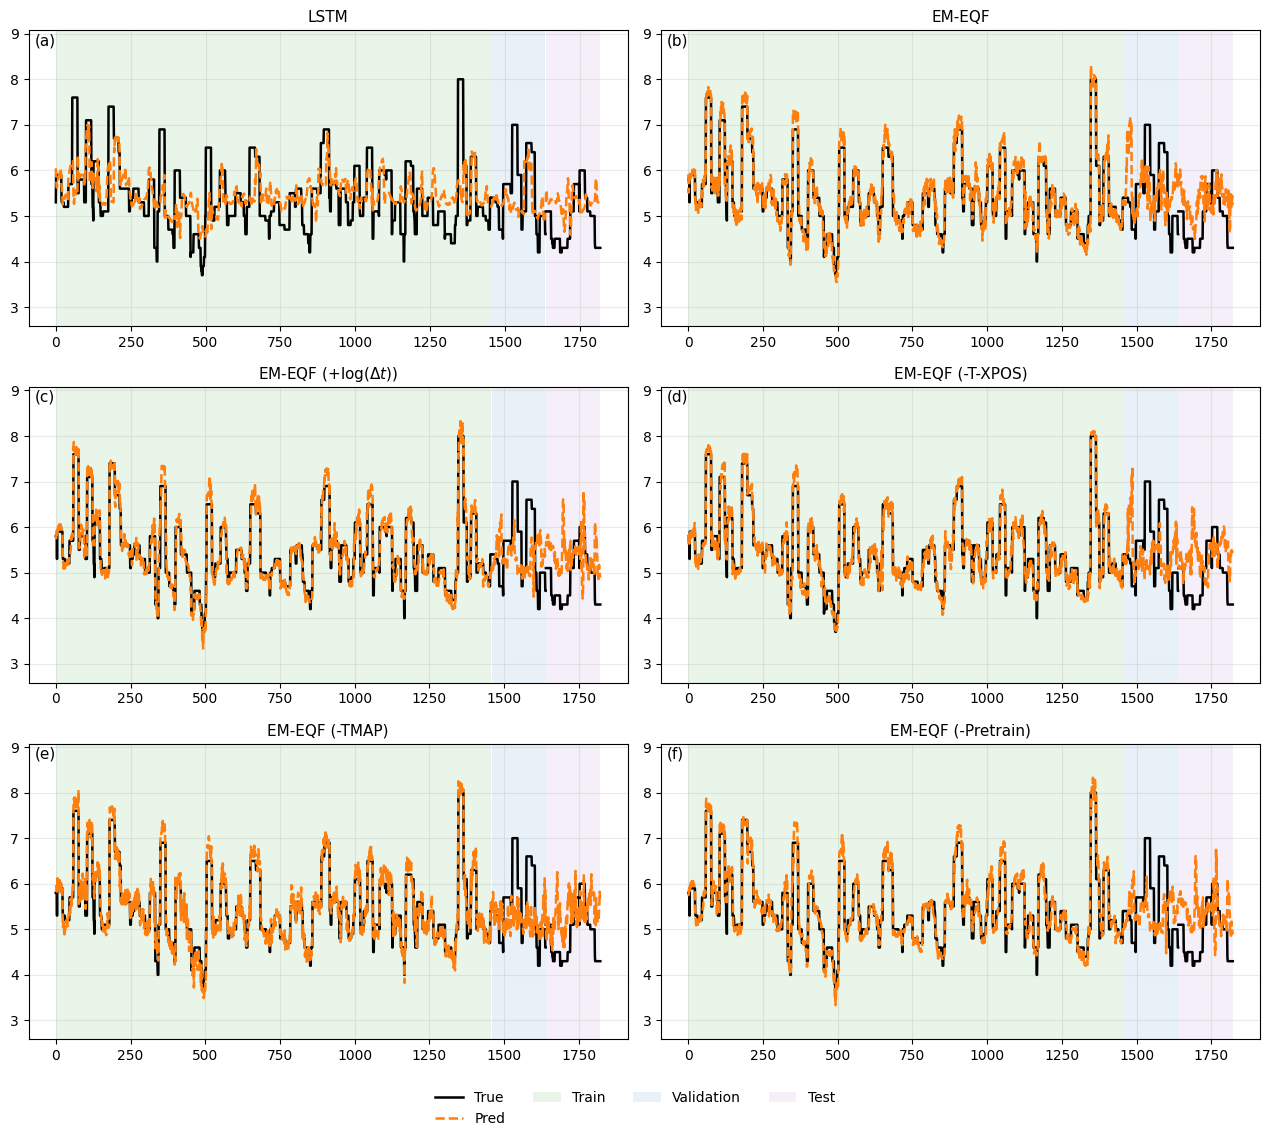

In [6]:
OUTPUT_PATH = FIG_DIR / 'regression_plots.pdf'

plot_multiple_regression_series(
    data_dicts=data_dicts,
    titles=titles,
    save_path=str(OUTPUT_PATH),
    verbose=True,
)


## 6) Bootstrap Metrics and Export

Compute bootstrap confidence intervals (paired block bootstrap on Test split) and support CSV/JSON export.


In [7]:
import pandas as pd
from src.utils.bootstrap_ci import BootstrapConfig
from src.utils.regression_compare_utils import (
    compute_regression_paired_block_bootstrap_tables as compute_regression_paired_block_bootstrap_tables_impl,
)

BOOTSTRAP_METRICS = ('rmse', 'mae', 'r2', 'mse')
BOOTSTRAP_SPLIT_ORDER = ('Test',)
BOOTSTRAP_USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP = True
BOOTSTRAP_SEED_AGG_METHOD = 'mean'  # 'mean' or 'median'
BOOTSTRAP_MODE = (
    'paired_block_hier_seed_sample'
    if BOOTSTRAP_USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP
    else 'paired_block'
)
BOOTSTRAP_BASELINE_MODEL = 'EM-EQF'  # None => use the first title in `titles` as baseline
BOOTSTRAP_CONFIG = BootstrapConfig(
    n_resamples=1000,
    ci=(2.5, 97.5),
    seed=42,
    sampling='block',
    block_size=4,
    circular_block=True,
)
BOOTSTRAP_SEED_CACHE_PATH = CACHE_DIR / 'reg_bootstrap_seed_data.pkl'
BOOTSTRAP_USE_SEED_CACHE = True
BOOTSTRAP_SAVE_SEED_CACHE = True


def compute_regression_paired_block_bootstrap_tables(
    data_dicts,
    titles,
    metrics=BOOTSTRAP_METRICS,
    config=BOOTSTRAP_CONFIG,
    split_order=BOOTSTRAP_SPLIT_ORDER,
    baseline_model=None,
    use_hierarchical_seed_sample=BOOTSTRAP_USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP,
    seed_aggregation=BOOTSTRAP_SEED_AGG_METHOD,
    experiments=None,
    device=DEVICE,
):
    """Delegate to shared regression bootstrap helper for notebook reuse."""

    return compute_regression_paired_block_bootstrap_tables_impl(
        data_dicts=data_dicts,
        titles=titles,
        metrics=metrics,
        config=config,
        split_order=split_order,
        baseline_model=baseline_model,
        use_hierarchical_seed_sample=use_hierarchical_seed_sample,
        seed_aggregation=seed_aggregation,
        experiments=experiments,
        device=device,
        project_root=PROJECT_ROOT,
        canonical_split_name_fn=canonical_split_name,
        get_data_dicts_from_checkpoints_fn=get_data_dicts_from_checkpoints,
        mode_label=BOOTSTRAP_MODE,
        seed_cache_path=BOOTSTRAP_SEED_CACHE_PATH,
        use_seed_cache=BOOTSTRAP_USE_SEED_CACHE,
        save_seed_cache=BOOTSTRAP_SAVE_SEED_CACHE,
    )



effective_baseline_model = BOOTSTRAP_BASELINE_MODEL or (titles[0] if len(titles) > 0 else None)
if effective_baseline_model is None:
    raise ValueError('No models found; cannot determine baseline model.')

bootstrap_metrics_df, bootstrap_pairwise_delta_df, bootstrap_common_n_seeds = compute_regression_paired_block_bootstrap_tables(
    data_dicts=data_dicts,
    titles=titles,
    baseline_model=effective_baseline_model,
    use_hierarchical_seed_sample=BOOTSTRAP_USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP,
    seed_aggregation=BOOTSTRAP_SEED_AGG_METHOD,
    experiments=EXPERIMENTS,
    device=DEVICE,
)

bootstrap_metrics_wide_df = (
    bootstrap_metrics_df
    .assign(
        point_ci=lambda d: d.apply(
            lambda r: f"{r['point_estimate']:.4f} [{r['ci_low']:.4f}, {r['ci_high']:.4f}]", axis=1
        )
    )
    .pivot(index=['split', 'metric'], columns='model', values='point_ci')
    .reset_index()
)

print(f'Bootstrap mode: {BOOTSTRAP_MODE}')
print(f'Bootstrap baseline model: {effective_baseline_model}')
print(f'Bootstrap config: {BOOTSTRAP_CONFIG}')
print(f'Use hierarchical seed+sample bootstrap: {BOOTSTRAP_USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP}')
if BOOTSTRAP_USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP:
    print(f'Seed aggregation method: {BOOTSTRAP_SEED_AGG_METHOD}')
    if bootstrap_common_n_seeds is not None:
        print(f'Common seeds used per model: {bootstrap_common_n_seeds}')
display(bootstrap_metrics_df)
display(bootstrap_metrics_wide_df)
display(bootstrap_pairwise_delta_df)




X shape: (1819, 5, 22), y shape: (1819,)
X_nl shape: (1819, 5, 22), y_nl shape: (1819,)
Saved bootstrap multi-seed cache to: /root/autodl-tmp/em_eqf/notebooks/cache/regression_comparison/reg_bootstrap_seed_data.pkl
Bootstrap mode: paired_block_hier_seed_sample
Bootstrap baseline model: EM-EQF
Bootstrap config: BootstrapConfig(n_resamples=1000, ci=(2.5, 97.5), seed=42, sampling='block', block_size=4, circular_block=True)
Use hierarchical seed+sample bootstrap: True
Seed aggregation method: mean
Common seeds used per model: 1


,mode,baseline_model,model,split,metric,n_obs,point_estimate,ci_low,ci_high,valid_resamples,total_resamples,n_model_seeds,ci_95
0,paired_block_hier_seed_sample,EM-EQF,LSTM,Test,rmse,183,0.721094,0.618135,0.814098,1000,1000,1,"[0.6181, 0.8141]"
1,paired_block_hier_seed_sample,EM-EQF,EM-EQF,Test,rmse,183,0.697120,0.607740,0.783704,1000,1000,1,"[0.6077, 0.7837]"
2,paired_block_hier_seed_sample,EM-EQF,EM-EQF (+$\log(\Delta t)$),Test,rmse,183,0.811965,0.657821,0.968295,1000,1000,1,"[0.6578, 0.9683]"
3,paired_block_hier_seed_sample,EM-EQF,EM-EQF (-T-XPOS),Test,rmse,183,0.826161,0.694768,0.957587,1000,1000,1,"[0.6948, 0.9576]"
4,paired_block_hier_seed_sample,EM-EQF,EM-EQF (-TMAP),Test,rmse,183,0.753158,0.652916,0.850918,1000,1000,1,"[0.6529, 0.8509]"
5,paired_block_hier_seed_sample,EM-EQF,EM-EQF (-Pretrain),Test,rmse,183,0.811965,0.657821,0.968295,1000,1000,1,"[0.6578, 0.9683]"
6,paired_block_hier_seed_sample,EM-EQF,LSTM,Test,mae,183,0.622390,0.518531,0.720230,1000,1000,1,"[0.5185, 0.7202]"
7,paired_block_hier_seed_sample,EM-EQF,EM-EQF,Test,mae,183,0.611577,0.523519,0.699537,1000,1000,1,"[0.5235, 0.6995]"
8,paired_block_hier_seed_sample,EM-EQF,EM-EQF (+$\log(\Delta t)$),Test,mae,183,0.649465,0.517765,0.792402,1000,1000,1,"[0.5178, 0.7924]"
9,paired_block_hier_seed_sample,EM-EQF,EM-EQF (-T-XPOS),Test,mae,183,0.685789,0.565637,0.809617,1000,1000,1,"[0.5656, 0.8096]"


model,split,metric,EM-EQF,EM-EQF (+$\log(\Delta t)$),EM-EQF (-Pretrain),EM-EQF (-T-XPOS),EM-EQF (-TMAP),LSTM
0,Test,mae,"0.6116 [0.5235, 0.6995]","0.6495 [0.5178, 0.7924]","0.6495 [0.5178, 0.7924]","0.6858 [0.5656, 0.8096]","0.6423 [0.5442, 0.7416]","0.6224 [0.5185, 0.7202]"
1,Test,mse,"0.4860 [0.3693, 0.6142]","0.6593 [0.4327, 0.9376]","0.6593 [0.4327, 0.9376]","0.6825 [0.4827, 0.9170]","0.5672 [0.4263, 0.7241]","0.5200 [0.3821, 0.6628]"
2,Test,r2,"-0.4523 [-1.2264, -0.0240]","-0.9702 [-2.1547, -0.3222]","-0.9702 [-2.1547, -0.3222]","-1.0397 [-2.2142, -0.3948]","-0.6951 [-1.6017, -0.1684]","-0.5539 [-1.2998, -0.1754]"
3,Test,rmse,"0.6971 [0.6077, 0.7837]","0.8120 [0.6578, 0.9683]","0.8120 [0.6578, 0.9683]","0.8262 [0.6948, 0.9576]","0.7532 [0.6529, 0.8509]","0.7211 [0.6181, 0.8141]"


,mode,baseline_model,split,metric,left_model,right_model,delta_name,point_estimate,ci_low,ci_high,valid_resamples,total_resamples,left_model_n_seeds,right_model_n_seeds,ci_95
0,paired_block_hier_seed_sample,EM-EQF,Test,rmse,LSTM,EM-EQF,LSTM - EM-EQF,0.023974,-0.071096,0.109558,1000,1000,1,1,"[-0.0711, 0.1096]"
1,paired_block_hier_seed_sample,EM-EQF,Test,rmse,EM-EQF (+$\log(\Delta t)$),EM-EQF,EM-EQF (+$\log(\Delta t)$) - EM-EQF,0.114844,-0.033695,0.274652,1000,1000,1,1,"[-0.0337, 0.2747]"
2,paired_block_hier_seed_sample,EM-EQF,Test,rmse,EM-EQF (-T-XPOS),EM-EQF,EM-EQF (-T-XPOS) - EM-EQF,0.129040,-0.013168,0.290913,1000,1000,1,1,"[-0.0132, 0.2909]"
3,paired_block_hier_seed_sample,EM-EQF,Test,rmse,EM-EQF (-TMAP),EM-EQF,EM-EQF (-TMAP) - EM-EQF,0.056037,-0.028589,0.152424,1000,1000,1,1,"[-0.0286, 0.1524]"
4,paired_block_hier_seed_sample,EM-EQF,Test,rmse,EM-EQF (-Pretrain),EM-EQF,EM-EQF (-Pretrain) - EM-EQF,0.114844,-0.033695,0.274652,1000,1000,1,1,"[-0.0337, 0.2747]"
5,paired_block_hier_seed_sample,EM-EQF,Test,mae,LSTM,EM-EQF,LSTM - EM-EQF,0.010813,-0.078580,0.096571,1000,1000,1,1,"[-0.0786, 0.0966]"
6,paired_block_hier_seed_sample,EM-EQF,Test,mae,EM-EQF (+$\log(\Delta t)$),EM-EQF,EM-EQF (+$\log(\Delta t)$) - EM-EQF,0.037888,-0.078394,0.174184,1000,1000,1,1,"[-0.0784, 0.1742]"
7,paired_block_hier_seed_sample,EM-EQF,Test,mae,EM-EQF (-T-XPOS),EM-EQF,EM-EQF (-T-XPOS) - EM-EQF,0.074212,-0.050643,0.207754,1000,1000,1,1,"[-0.0506, 0.2078]"
8,paired_block_hier_seed_sample,EM-EQF,Test,mae,EM-EQF (-TMAP),EM-EQF,EM-EQF (-TMAP) - EM-EQF,0.030709,-0.060610,0.124865,1000,1000,1,1,"[-0.0606, 0.1249]"
9,paired_block_hier_seed_sample,EM-EQF,Test,mae,EM-EQF (-Pretrain),EM-EQF,EM-EQF (-Pretrain) - EM-EQF,0.037888,-0.078394,0.174184,1000,1000,1,1,"[-0.0784, 0.1742]"


In [7]:
EXPORT_BOOTSTRAP = True
BOOTSTRAP_EXPORT_DIR = METRIC_EXPORT_DIR
BOOTSTRAP_EXPORT_STEM = f'regression_comparison_bootstrap_metrics_{BOOTSTRAP_MODE}'

if EXPORT_BOOTSTRAP:
    long_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_long.csv'
    wide_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_wide.csv'
    pair_delta_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_pairwise_delta.csv'
    json_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_long.json'
    pair_delta_json_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_pairwise_delta.json'

    bootstrap_metrics_df.to_csv(long_csv_path, index=False)
    bootstrap_metrics_wide_df.to_csv(wide_csv_path, index=False)
    bootstrap_pairwise_delta_df.to_csv(pair_delta_csv_path, index=False)
    bootstrap_metrics_df.to_json(json_path, orient='records', force_ascii=False, indent=2)
    bootstrap_pairwise_delta_df.to_json(pair_delta_json_path, orient='records', force_ascii=False, indent=2)

    print(f'Bootstrap long CSV exported: {long_csv_path}')
    print(f'Bootstrap wide CSV exported: {wide_csv_path}')
    print(f'Bootstrap pairwise delta CSV exported: {pair_delta_csv_path}')
    print(f'Bootstrap JSON exported: {json_path}')
    print(f'Bootstrap pairwise delta JSON exported: {pair_delta_json_path}')
else:
    print('EXPORT_BOOTSTRAP=False, skip export.')


Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_long.csv
Bootstrap wide CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_wide.csv
Bootstrap pairwise delta CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_pairwise_delta.csv
Bootstrap JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_long.json
Bootstrap pairwise delta JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_pairwise_delta.json
